# poking at the data

just looking around before I decide what to do with it. whatever's actually
useful gets rewritten properly in `notebooks/01_exploration.ipynb`, this is
just me finding out what I'm holding. 
Will look to flag things and send to other notebooks to really explore if need be 
and will end with what I did and where I am going next

want to know: how many rows/cols, is the split balanced (if it's way off,
randomisation is suspect and nothing downstream means much), any duplicate
userids (breaks independence), and what do the outcomes actually look like.

In [2]:
import sys
from pathlib import Path

# Make `src` importable regardless of where the notebook is launched from.
repo_root = Path.cwd()
while not (repo_root / "src").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_data

df, source = load_data()

Real Cookie Cats data loaded from /Users/koonima/DS_playground/bayesian-ab-test/data/cookie_cats.csv
Loaded 90,189 rows x 5 columns


In [3]:
df.head(10)

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
5,540,gate_40,187,True,True
6,1066,gate_30,0,False,False
7,1444,gate_40,2,False,False
8,1574,gate_40,108,True,True
9,1587,gate_40,153,True,False


In [4]:
print(df.shape)
print()
print(df.dtypes)
print()
print(df.isna().sum())

(90189, 5)

userid             int64
version           object
sum_gamerounds     int64
retention_1         bool
retention_7         bool
dtype: object

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64


no missing values, retention cols already bool. nice.

kind of suspicious actually for "real" data to have zero missing values anywhere. keeping an eye on it, not assuming it's fake though.

In [5]:
# Balance check. Random assignment should give roughly equal arms.
counts = df["version"].value_counts()
print(counts)

n_total = len(df)
imbalance = abs(counts.iloc[0] - counts.iloc[1])
print(f"imbalance: {imbalance:,} users ({imbalance/n_total:.3%} of total)")

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64
imbalance: 789 users (0.875% of total)


not that eyecatching on its own honestly, let me look at it relative instead

In [7]:
# Relative difference compared to the smaller arm
# should be about double the imbalance since I expecte 50/50 split
smaller_arm_count = counts.min()
rel_imbalance = imbalance / smaller_arm_count

print(f"imbalance: {imbalance:,} users ({imbalance/n_total:.3%} of total)")
print(f"relative imbalance: {rel_imbalance:.3%} more users in larger arm")

imbalance: 789 users (0.875% of total)
relative imbalance: 1.765% more users in larger arm


so ~1.8% more users in one arm than the other. is that actually a problem or am I pattern matching on nothing

lets look at it under a fair 50/50 coin flip w n ~90_000, how surprising is a split this uneven really

scipy.stats.binom since there's only two groups

In [8]:
from scipy import stats

n_total = len(df)
n_control = int(counts.get("gate_30", 0))

# Two-sided binomial test: is the observed split consistent with p = 0.5?
result = stats.binomtest(n_control, n_total, 0.5)
print(f"observed split: {n_control:,} / {n_total:,} = {n_control/n_total:.4f}")
print(f"binomial test p-value: {result.pvalue:.4f}")

observed split: 44,700 / 90,189 = 0.4956
binomial test p-value: 0.0087


ok p-value is small so this isn't rounding noise, it's a real SRM (sample
ratio mismatch).

SRM happens in production A/B tests all the time for
boring reasons: bot filtering hitting one arm more, people dropping before
their assignment got logged, a variant that fails to load more often than the
other. could also mean assignment is actually broken, in which case
everything downstream here is confounded and none of it means anything.

can't tell which from just a csv, that needs the actual assignment logs. what
I *can* do is check whether the imbalance lines up with anything observable.

In [9]:
# Duplicate users would break independence.
print("total rows:", f"{len(df):,}")
print("unique userids:", f"{df['userid'].nunique():,}")
print("duplicated rows:", f"{df['userid'].duplicated().sum():,}")

total rows: 90,189
unique userids: 90,189
duplicated rows: 0


In [10]:
# Outcome variables
for outcome in ["retention_1", "retention_7"]:
    print(outcome)
    print(df.groupby("version")[outcome].agg(["count", "sum", "mean"]))
    print()

retention_1
         count    sum      mean
version                        
gate_30  44700  20034  0.448188
gate_40  45489  20119  0.442283

retention_7
         count   sum      mean
version                       
gate_30  44700  8502  0.190201
gate_40  45489  8279  0.182000



first real thing worth flagging: the two outcomes point in different
directions.

- retention_1 - arms basically identical
- retention_7 - control ahead by ~0.01

matters for how this gets told. if I only showed the 7-day number it'd read
like a cleaner story than what's actually here.

also — I'm now looking at two outcomes, and if I test both and report
whichever comes back significant my real false positive rate isn't 5%
anymore. so deciding now, before running anything: retention_7 is primary,
retention_1 is secondary and gets reported no matter what it shows. 

Want this done before so not to confound myself. Also 7-day makes more sens as it is the longer retention which is what we would want as it is stronger to have someone for a week over just a day. 

In [12]:
# Game rounds — the only continuous variable here.
print(df["sum_gamerounds"].describe())
print()

print("zero-round users:", f"{(df['sum_gamerounds'] == 0).sum():,}")
print("max:", f"{df['sum_gamerounds'].max():,}")

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

zero-round users: 3,994
max: 49,854


mean's ~52, median ~16, and the max is in the tens of thousands?? either a
genuinely wild user, a bot, or a logging bug. 

will look at it in another notebook. 

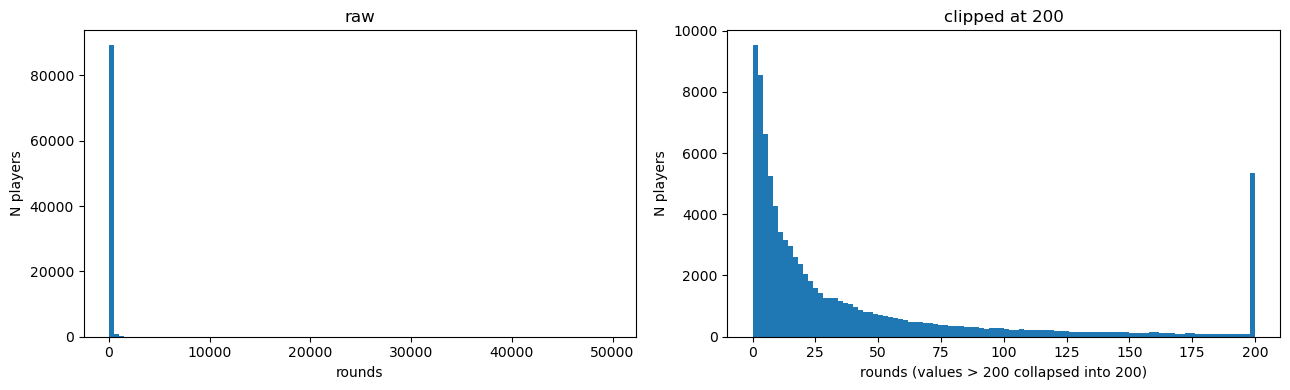

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df["sum_gamerounds"], bins=100)
axes[0].set_title("raw")
axes[0].set_xlabel("rounds")
axes[0].set_ylabel("N players")

axes[1].hist(df["sum_gamerounds"].clip(upper=200), bins=100)
axes[1].set_title("clipped at 200")
axes[1].set_xlabel("rounds")
axes[1].set_ylabel("N players")
plt.tight_layout()
plt.show()

The clip was kind of dumb as it adds the others above 200 to be at 200 hence the spike. Look at lines for different view

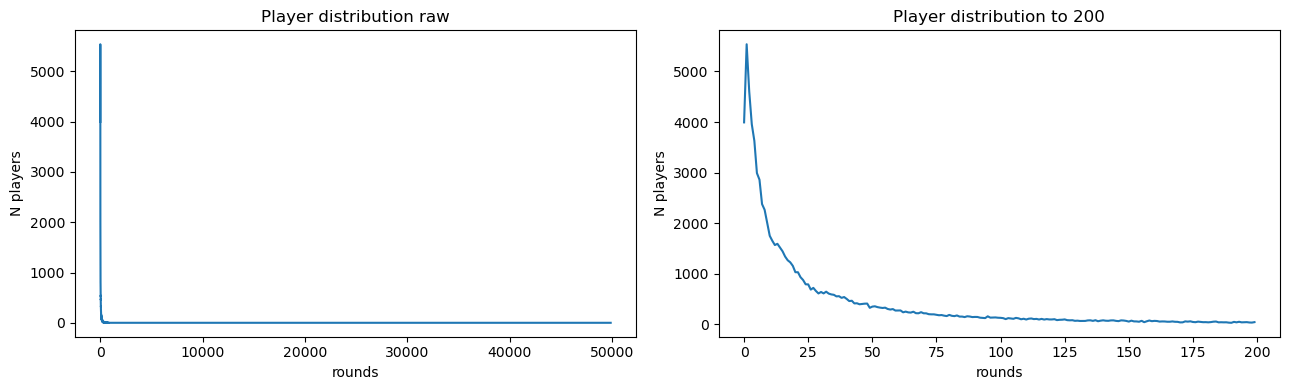

In [23]:
plot_df = df.groupby("sum_gamerounds")["userid"].count()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_df.plot(ax=axes[0])
axes[0].set_title("Player distribution raw")
axes[0].set_xlabel("rounds")
axes[0].set_ylabel("N players")

plot_df.head(200).plot(ax=axes[1])
axes[1].set_title("Player distribution to 200")
axes[1].set_xlabel("rounds")
axes[1].set_ylabel("N players")

plt.tight_layout()
plt.show()

recap so far so I don't lose the thread:
- data's clean — no missing values, no dupe userids
- arms close to balanced, small mismatch noted but not treating as fatal
- retention_7 = primary outcome, decided before running any test
- sum_gamerounds has at least one insane outlier, need to check if it matters
- retention_1 and retention_7 disagree in direction — report both

next: the outlier thing